# Day 2: Preprocessing Pipelines & Model Training

Continuing from Day 1: same data load, target definition, and 70/10/20 stratified split. Primary metric remains **ROC AUC**, as justified in Task 1.

## Setup: Load Data & Recreate Day 1 Split

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [3]:
adult = fetch_openml('adult', version=2, as_frame=True)
df_raw = adult.frame.copy()

# Same target fix as Day 1 
df_raw['income'] = (df_raw['class'].str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)
df_raw = df_raw.drop(columns=['class'])

df_raw = df_raw.replace(' ?', np.nan).replace('?', np.nan)

In [4]:
X = df_raw.drop(columns=['income'])
y = df_raw['income']

# First split off the 20% hold-out test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Then split remaining 80% into 70% train / 10% dev
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Dev:", X_dev.shape, "Test:", X_test.shape)
print("Base rates — train:", y_train.mean().round(3), "dev:", y_dev.mean().round(3), "test:", y_test.mean().round(3))

Train: (34188, 14) Dev: (4885, 14) Test: (9769, 14)
Base rates — train: 0.239 dev: 0.239 test: 0.239


## Task 1: Preprocessing Plan & Implementation

Numeric and categorical features are separated and passed through a `ColumnTransformer`, fit only on training data to avoid leakage.

In [5]:
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                         'relationship', 'race', 'sex', 'native-country']

In [6]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

## Task 2: Train Two Supervised Models (in Pipelines)

In [7]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=1000))
])
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [8]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6))
])
tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

## Task 3: Evaluate on Hold-Out Test (Multiple Metrics)

Primary metric: **ROC AUC** (as established in Day 1) — reported alongside accuracy, precision, recall, F1, and PR AUC for completeness.

In [9]:
def evaluate_model(pipeline, X_test, y_test, model_name):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'PR AUC': average_precision_score(y_test, y_proba)
    }, y_pred, y_proba

log_reg_metrics, log_reg_pred, log_reg_proba = evaluate_model(log_reg_pipeline, X_test, y_test, "Logistic Regression")
tree_metrics, tree_pred, tree_proba = evaluate_model(tree_pipeline, X_test, y_test, "Decision Tree")

results_df = pd.DataFrame([log_reg_metrics, tree_metrics]).set_index('Model')
print(results_df.round(3))

                     Accuracy  Precision  Recall     F1  ROC AUC  PR AUC
Model                                                                   
Logistic Regression     0.853      0.743   0.588  0.656    0.904   0.762
Decision Tree           0.856      0.819   0.514  0.631    0.896   0.734


In [10]:
day1_baselines = pd.DataFrame([
    {'Model': 'Majority Class', 'Accuracy': 0.761, 'Precision': 0.000, 'Recall': 0.000, 'F1': 0.000, 'ROC AUC': 0.500, 'PR AUC': 0.239},
    {'Model': 'Rule: education-num ≥ 13', 'Accuracy': 0.753, 'Precision': 0.484, 'Recall': 0.497, 'F1': 0.491, 'ROC AUC': 0.719, 'PR AUC': 0.444},
]).set_index('Model')

comparison_df = pd.concat([day1_baselines, results_df])
print(comparison_df.round(3))

                          Accuracy  Precision  Recall     F1  ROC AUC  PR AUC
Model                                                                        
Majority Class               0.761      0.000   0.000  0.000    0.500   0.239
Rule: education-num ≥ 13     0.753      0.484   0.497  0.491    0.719   0.444
Logistic Regression          0.853      0.743   0.588  0.656    0.904   0.762
Decision Tree                0.856      0.819   0.514  0.631    0.896   0.734


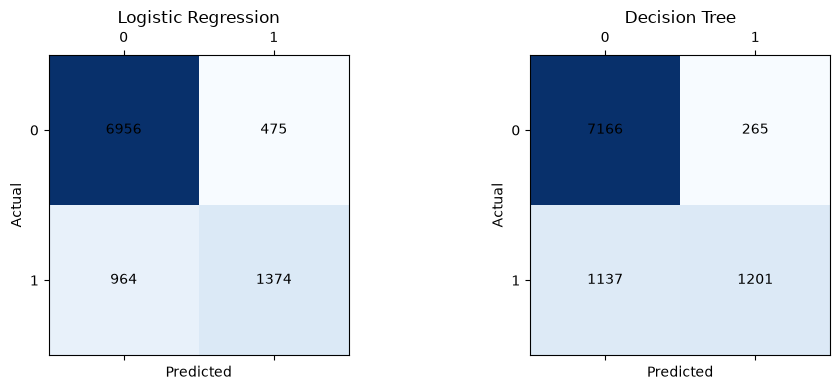

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, name in zip(axes, [log_reg_pred, tree_pred], ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, pred)
    ax.matshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

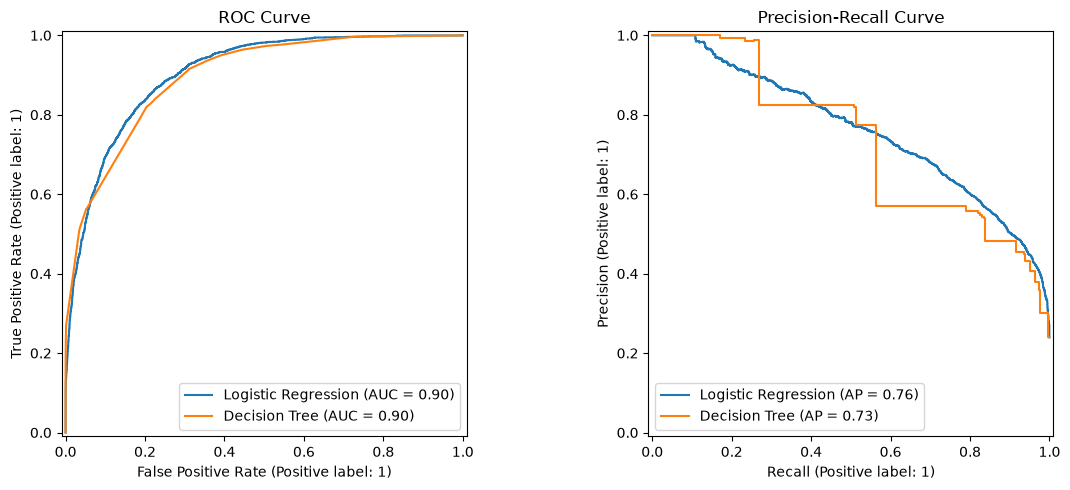

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(log_reg_pipeline, X_test, y_test, ax=axes[0], name="Logistic Regression")
RocCurveDisplay.from_estimator(tree_pipeline, X_test, y_test, ax=axes[0], name="Decision Tree")
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_estimator(log_reg_pipeline, X_test, y_test, ax=axes[1], name="Logistic Regression")
PrecisionRecallDisplay.from_estimator(tree_pipeline, X_test, y_test, ax=axes[1], name="Decision Tree")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

## Task 4: Interpretability Check

In [13]:
feature_names = log_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = log_reg_pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients}).sort_values('coefficient', ascending=False)

print("Top 10 positive:\n", coef_df.head(10))
print("\nTop 10 negative:\n", coef_df.tail(10))

Top 10 positive:
                                    feature  coefficient
3                        num__capital-gain     2.222385
32  cat__marital-status_Married-civ-spouse     1.586274
31   cat__marital-status_Married-AF-spouse     1.224663
84             cat__native-country_Ireland     1.074746
73              cat__native-country_France     0.829463
40         cat__occupation_Exec-managerial     0.788377
72             cat__native-country_England     0.764739
56                  cat__relationship_Wife     0.761869
2                       num__education-num     0.756381
64            cat__native-country_Cambodia     0.706264

Top 10 negative:
                                  feature  coefficient
35         cat__marital-status_Separated    -0.844279
44         cat__occupation_Other-service    -0.862866
98             cat__native-country_South    -0.907679
41       cat__occupation_Farming-fishing    -0.915998
101  cat__native-country_Trinadad&Tobago    -0.941629
53      cat__relationsh

In [14]:
tree_clf = tree_pipeline.named_steps['classifier']
print("Tree depth:", tree_clf.get_depth())
print("Train accuracy:", round(tree_pipeline.score(X_train, y_train), 3))
print("Test accuracy:", round(tree_pipeline.score(X_test, y_test), 3))

Tree depth: 6
Train accuracy: 0.855
Test accuracy: 0.856


In [15]:
tree_feature_names = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()
print(export_text(tree_clf, feature_names=list(tree_feature_names), max_depth=2))

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.83
|   |   |--- num__education-num <= 0.94
|   |   |   |--- truncated branch of depth 4
|   |   |--- num__education-num >  0.94
|   |   |   |--- truncated branch of depth 4
|   |--- num__capital-gain >  0.83
|   |   |--- num__age <= -1.33
|   |   |   |--- truncated branch of depth 2
|   |   |--- num__age >  -1.33
|   |   |   |--- truncated branch of depth 4
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.55
|   |   |--- num__capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 4
|   |   |--- num__capital-gain >  0.56
|   |   |   |--- truncated branch of depth 4
|   |--- num__education-num >  0.55
|   |   |--- num__capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 4
|   |   |--- num__capital-gain >  0.56
|   |   |   |--- truncated branch of depth 4



## Task 5: Write-Up & Model Selection for Day 3

**Comparison:** [Fill in from `comparison_df` — did either model clear the 0.85 ROC AUC target you set in Day 1?]

**Decision:** [Which model(s) continue to Day 3, and why.]

**Preprocessing changes to test tomorrow** (from Day 1's checklist):
1. log1p transform or binary flag for capital-gain/capital-loss
2. Drop redundant `education` string column, keep `education-num`
3. Simplify `marital-status` to married/not-married
4. Try `class_weight='balanced'` given ~24% positive rate

In [17]:
import joblib
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(log_reg_pipeline, 'log_reg_pipeline.joblib')
joblib.dump(tree_pipeline, 'tree_pipeline.joblib')

['tree_pipeline.joblib']